In [2]:
import sys
sys.path.append("../../")

from biked_commons.resource_utils import resource_path, models_and_scalers_path
from biked_commons.usability.mlp_model import MLP
from biked_commons.usability.usability_ordered_columns import ORDERED_COLUMNS
from biked_commons.resource_utils import split_datasets_path
import pandas as pd
import numpy as np

from sklearn.metrics import r2_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, TensorDataset
from sklearn.model_selection import KFold
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import optuna
from pytorch_lightning.callbacks import EarlyStopping
import pytorch_lightning as pl

c:\Users\fabie\.pyenv\pyenv-win\versions\3.9.10\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:

data = pd.read_csv(split_datasets_path("bike_bench.csv"), index_col=0)[ORDERED_COLUMNS]
data_scaler = MinMaxScaler()
data[data.columns] = data_scaler.fit_transform(data[data.columns])

X_test_index = pd.read_csv(split_datasets_path("usability_cont_norm_X_test.csv"), index_col=0).index
X_train_index = pd.read_csv(split_datasets_path("usability_cont_norm_X_train.csv"), index_col=0).index
y_test = pd.read_csv(split_datasets_path("usability_cont_y_test.csv"), index_col=0)
y_train = pd.read_csv(split_datasets_path("usability_cont_y_train.csv"), index_col=0)

X_test = data.loc[X_test_index]
X_train = data.loc[X_train_index]   

In [5]:
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from pytorch_lightning.callbacks.model_checkpoint import ModelCheckpoint
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import KFold
import pytorch_lightning as pl
import torch.nn as nn
import torch
import torchmetrics

class MLP(pl.LightningModule):
    def __init__(self, input_dim, hidden_dims, dropout_rate, lr):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, 1))  # Output layer
        self.network = nn.Sequential(*layers)
        self.lr = lr
        self.criterion = nn.MSELoss()
        self.val_mse = torchmetrics.MeanSquaredError()

    def forward(self, x):
        return self.network(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = self.criterion(y_pred, y)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = self.criterion(y_pred, y)
        self.val_mse(y_pred, y)
        self.log("val_loss", loss, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return optim.Adam(self.parameters(), lr=self.lr)


def objective(trial, input_dim, dataset, k_folds):
    # Define hyperparameter search space
    num_layers = trial.suggest_int("num_layers", 1, 4)
    hidden_dims = [trial.suggest_int(f"n_units_l{i}", 32, 512, step=32) for i in range(num_layers)]
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5)
    lr = trial.suggest_loguniform("lr", 1e-4, 1e-2)
    batch_size = trial.suggest_int("batch_size", 4, 28, step=4)

    kfold = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    val_losses = []
    best_epochs = []

    for train_idx, val_idx in kfold.split(dataset):
        train_subset = Subset(dataset, train_idx)
        val_subset = Subset(dataset, val_idx)

        train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_subset, batch_size=batch_size)

        model = MLP(input_dim=input_dim, hidden_dims=hidden_dims, dropout_rate=dropout_rate, lr=lr)

        early_stop_callback = EarlyStopping(
            monitor="val_loss",  
            patience=20,          
            verbose=True,        
            mode="min",           
        )

        trainer = pl.Trainer(
            max_epochs=200,
            enable_progress_bar=False,
            logger=False,
            callbacks=[early_stop_callback],  
        )

        trainer.fit(model, train_loader, val_loader)

        # Extract validation loss and best epoch
        val_loss = trainer.callback_metrics["val_loss"].item()
        val_losses.append(val_loss)
        best_epochs.append(trainer.current_epoch)  # Track best epoch

    # Store best epoch as a user attribute for later analysis
    trial.set_user_attr("best_epoch", sum(best_epochs) / len(best_epochs))

    return sum(val_losses) / len(val_losses)  # Return average CV loss




In [7]:
def test_model(model, X_t, y_t, batch_size = 32):
    dataset = TensorDataset(X_t, y_t)

    test_loader = DataLoader(dataset, batch_size=batch_size)

    # Set model to evaluation mode
    model.eval()

    test_losses = []
    criterion = nn.MSELoss()

    # No gradient updates needed
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            test_losses.append(loss.item())

    # Compute final test loss
    final_test_loss = sum(test_losses) / len(test_losses)
    print(f"Final Test MSE: {final_test_loss:.4f}")


    model.eval()

    all_true = []
    all_pred = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            y_hat = model(X_batch)
            
            all_true.append(y_batch.numpy())
            all_pred.append(y_hat.numpy())

    all_true = np.concatenate(all_true, axis=0)
    all_pred = np.concatenate(all_pred, axis=0)

    r2 = r2_score(all_true, all_pred)
    print(f"Final Test R2: {r2:.4f}")

    return final_test_loss, r2


# Scatter plot to compare true vs predicted
def plots(model, X_t, y_t, batch_size = 32):
    dataset = TensorDataset(X_t, y_t)

    test_loader = DataLoader(dataset, batch_size=batch_size)

    all_true = []
    all_pred = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            y_hat = model(X_batch)
            
            all_true.append(y_batch.numpy())
            all_pred.append(y_hat.numpy())

    all_true = np.concatenate(all_true, axis=0)
    all_pred = np.concatenate(all_pred, axis=0)

    plt.figure(figsize=(8, 6))
    plt.scatter(all_true, all_pred, color='blue', alpha=0.6)
    plt.plot([min(all_true), max(all_true)], [min(all_true), max(all_true)], color='red', linestyle='--')  # 45-degree line
    plt.xlabel("True Values")
    plt.ylabel("Predicted Values")
    plt.title("True vs Predicted Values")
    plt.show()

    # Residual plot
    plt.figure(figsize=(8, 6))
    residuals = all_true - all_pred
    plt.scatter(all_pred, residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')  # Zero residual line
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    plt.show()



In [6]:
random.seed(42)  # For Python's random module
np.random.seed(42)  # For NumPy
torch.manual_seed(42)  # For PyTorch (CPU)
torch.cuda.manual_seed_all(42)  # For PyTorch (GPU)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


INPUT_DIMENSION = 3

X = torch.tensor(X_train.values, dtype=torch.float32)  # Convert to Tensor
y = torch.tensor(y_train.values.ravel(), dtype=torch.float32).unsqueeze(1)  # Convert & reshape

dataset = TensorDataset(X, y)
k_folds = 5  

study_k_norm = None
study_k_norm = optuna.create_study(direction="minimize")

if __name__ == "__main__":
    study_k_norm.optimize(lambda trial: objective(trial,INPUT_DIMENSION, dataset, k_folds), n_trials=30 , n_jobs=-1)

print("Best hyperparameters:", study_k_norm.best_params)
print("Best validation loss:", study_k_norm.best_value)


[I 2025-04-25 14:29:12,408] A new study created in memory with name: no-name-c6996a4e-5bee-4821-959c-37738a0d0b75


C:\Users\fabie\AppData\Local\Temp\ipykernel_32784\1069791587.py:52: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("lr", 1e-4, 1e-2)
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
You are usin

Best hyperparameters: {'num_layers': 2, 'n_units_l0': 160, 'n_units_l1': 512, 'dropout_rate': 0.14037052531625702, 'lr': 0.0027234315924487837, 'batch_size': 4}
Best validation loss: 0.03586067818105221


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\fabie\.pyenv\pyenv-win\versions\3.9.10\lib\site-packages\pytorch_lightning\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name      | Type             | Params | Mode 
-------------------------------------------------------
0 | network   | Sequential       | 83.6 K | train
1 | criterion | MSELoss          | 0      | train
2 | val_mse   | MeanSquaredError | 0      | train
-------------------------------------------------------
83.6 K    Trainable params
0         Non-trainable params
83.6 K    Total params
0.334     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode
`Trainer.fit` stopped: `max_epochs=99` reached

Final Test MSE: 0.0254
Final Test R2: 0.4374


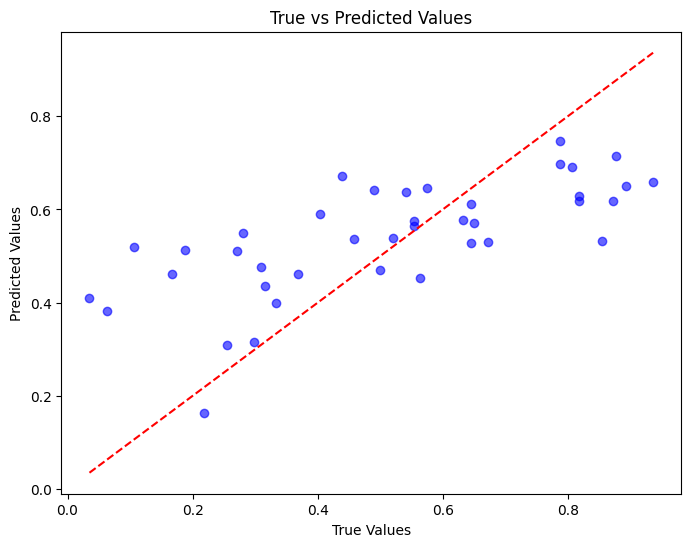

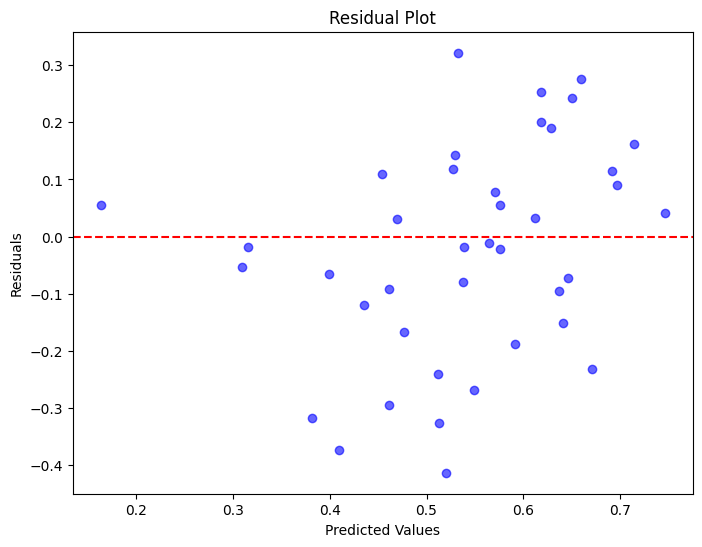

In [ ]:
INPUT_DIMENSION = 3
best_params = study_k_norm.best_params


final_model = MLP(
    input_dim=INPUT_DIMENSION,
    hidden_dims=[best_params[f"n_units_l{i}"] for i in range(best_params["num_layers"])],
    dropout_rate=best_params["dropout_rate"],
    lr=best_params["lr"]
)


X = torch.tensor(X_train.values, dtype=torch.float32)  
y = torch.tensor(y_train.values.ravel(), dtype=torch.float32).unsqueeze(1)  

dataset = TensorDataset(X, y)

final_train_loader = DataLoader(dataset, batch_size=best_params["batch_size"])

trainer = pl.Trainer(
    max_epochs=int(study_k_norm.best_trial.user_attrs["best_epoch"]),
    enable_progress_bar=False,
    logger=False,
)

trainer.fit(final_model, final_train_loader)

torch.save(final_model.state_dict(), "final_mlp_model_key_features_norm1.pth")


X_t = torch.tensor(X_test.values, dtype=torch.float32)  
y_t = torch.tensor(y_test.values.ravel(), dtype=torch.float32).unsqueeze(1)  

test_model(final_model, X_t, y_t)
plots(final_model, X_t, y_t)

In [10]:
checkpoint = {
    'model_state_dict': final_model.state_dict(),
    'hyperparameters': {
        "input_dim": INPUT_DIMENSION,
        "hidden_dims": [best_params[f"n_units_l{i}"] for i in range(best_params["num_layers"])],
        "dropout_rate": best_params["dropout_rate"],
        "lr": best_params["lr"],
        "num_layers": best_params["num_layers"]
    }
}

torch.save(checkpoint, "mlp_with_hyperparameters.pth")


In [11]:
import pickle
with open('scaler_usability.pk', 'wb') as file:
    pickle.dump(data_scaler, file)